In [1]:
# =========================
# Install & Setup
# =========================

!pip install nltk scikit-learn pandas matplotlib

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
# =========================
# Download Dataset Automatically
# =========================

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip

# Unzip file
!unzip smsspamcollection.zip

--2026-04-17 16:07:11--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip’

smsspamcollection.z     [   <=>              ] 198.65K   346KB/s    in 0.6s    

2026-04-17 16:07:13 (346 KB/s) - ‘smsspamcollection.zip’ saved [203415]

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [6]:
# =========================
# Load Dataset
# =========================

import pandas as pd

df = pd.read_csv("SMSSpamCollection", sep='\t', names=["label", "message"])

# Convert labels
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (5572, 2)
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [7]:
# =========================
# Text Preprocessing
# =========================

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean'] = df['message'].apply(preprocess)

print(df[['message', 'clean']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                               clean  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4             nah think goes usf lives around though  


In [8]:
# =========================
# Train-Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'], test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4457
Test size: 1115


In [9]:
# =========================
# TF-IDF Vectorization
# =========================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (4457, 3000)


In [10]:
# =========================
# Naive Bayes (TF-IDF)
# =========================

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("=== Naive Bayes (TF-IDF) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

=== Naive Bayes (TF-IDF) ===
Accuracy: 0.9829596412556054
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [11]:
# =========================
# Baseline: Bag of Words
# =========================

from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=3000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

y_pred_bow = nb_bow.predict(X_test_bow)

print("=== Naive Bayes (BoW) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))

=== Naive Bayes (BoW) ===
Accuracy: 0.9829596412556054
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.93      0.94      0.94       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [12]:
# =========================
# Model Comparison
# =========================

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "SVM": SVC(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))


=== SVM ===
Accuracy: 0.9874439461883409
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       1.00      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115


=== Decision Tree ===
Accuracy: 0.9488789237668162
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       966
           1       0.76      0.91      0.83       149

    accuracy                           0.95      1115
   macro avg       0.87      0.93      0.90      1115
weighted avg       0.95      0.95      0.95      1115


=== KNN ===
Accuracy: 0.9264573991031391
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       966
           1       1.00      0.45      0.62       149

    accuracy                           0.93   

In [13]:
# =========================
# Confusion Matrix
# =========================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[964   2]
 [ 17 132]]


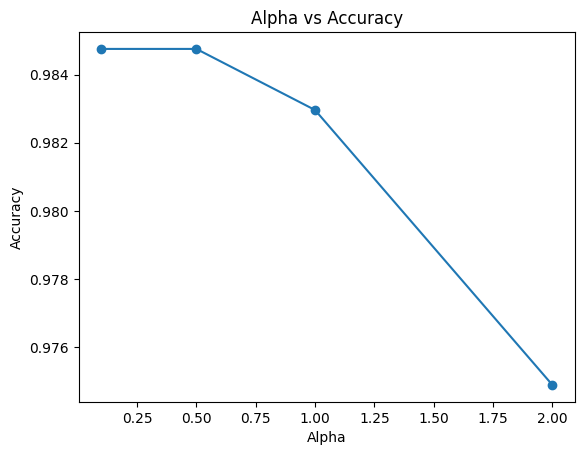

In [14]:
# =========================
# Alpha Sensitivity (Ablation)
# =========================

alphas = [0.1, 0.5, 1.0, 2.0]
results = []

for a in alphas:
    model = MultinomialNB(alpha=a)
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)
    results.append(acc)

plt.figure()
plt.plot(alphas, results, marker='o')
plt.title("Alpha vs Accuracy")
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.show()

In [15]:
# =========================
# Error Analysis (False Negatives)
# =========================

false_negatives = []

for i in range(len(y_test)):
    if y_test.iloc[i] == 1 and y_pred_nb[i] == 0:
        false_negatives.append(X_test.iloc[i])

print("Some False Negatives (Missed Spam):\n")
for msg in false_negatives[:10]:
    print("-", msg)

Some False Negatives (Missed Spam):

- guess somebody know secretly fancies wanna find give us call landline datebox essexcm xn p min
- oh god found number glad text back xafter msgs cst std ntwk chg
- next amazing xxx picsfree video sent enjoy one vid enough day text back keyword picsfree get next video
- babe u want dont u baby im nasty thing filthyguys fancy rude time sexy bitch go slo n hard txt xxx slo msgs
- want cock hubby away need real man satisfy txt wife strings action txt stop end txt rec ea otbox la ws
- hello darling today would love chat dont tell look like sexy
- guess somebody know secretly fancies wanna find give us call landline datebox essexcm xn p min
- realize years thousands old ladies running around tattoos
- text banneduk see cost p textoperator g ga xxx
- u meet ur dream partner soon ur career flyng start find free txt horo followed ur star sign e g horo aries
